# Random Forest

## Concept

Random Forest is an **ensemble machine learning algorithm**.

Instead of using one decision tree, Random Forest builds **many decision trees** and combines their predictions.

The final prediction is decided by **majority voting** (for classification) or **averaging** (for regression).

Why this works:

A single decision tree may overfit the training data.

But when we combine many trees trained on different subsets of the data, the model becomes **more robust and accurate**.

This idea is called **ensemble learning**.

Random Forest uses two important techniques:

1. Bootstrap Sampling  
2. Feature Randomness

Bootstrap Sampling means each tree is trained on a random subset of the dataset.

Feature Randomness means each split considers a random subset of features.

Pipeline:

Dataset
→ Create multiple bootstrap samples
→ Train many decision trees
→ Combine predictions
→ Final output

# Math Behind Random Forest

Random Forest uses the concept of **Bagging (Bootstrap Aggregation)**.

Step 1: Generate bootstrap datasets.

Example:

Original dataset size = N

Each tree receives a random sample of size N
drawn **with replacement**.

Step 2: Train independent decision trees.

Step 3: Combine predictions.

Classification:

Final Prediction = Majority Vote

Regression:

Final Prediction = Average of predictions

Mathematically:

Prediction = (1 / T) * Σ tree_predictions

Where:

T = number of trees

This reduces **variance** and improves generalization.

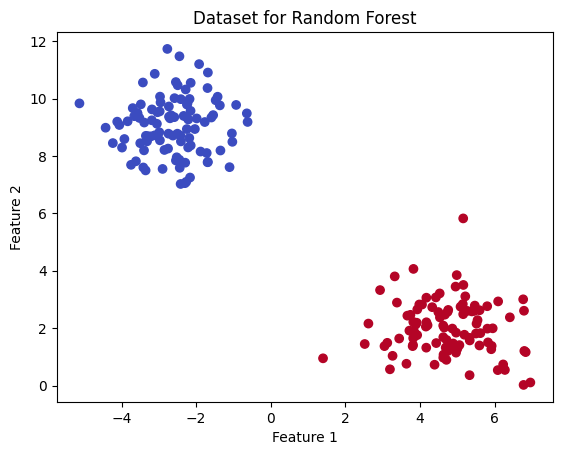

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=200, centers=2, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm")
plt.title("Dataset for Random Forest")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

This dataset will be used to demonstrate ensemble learning

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

data = load_iris()

X_train, X_test, y_train, y_test = train_test_split(
    data.data,
    data.target,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(predictions[:10])

[1 0 2 1 1 0 1 2 1 1]


In [3]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


Random Forest usually performs better than a single decision tree.

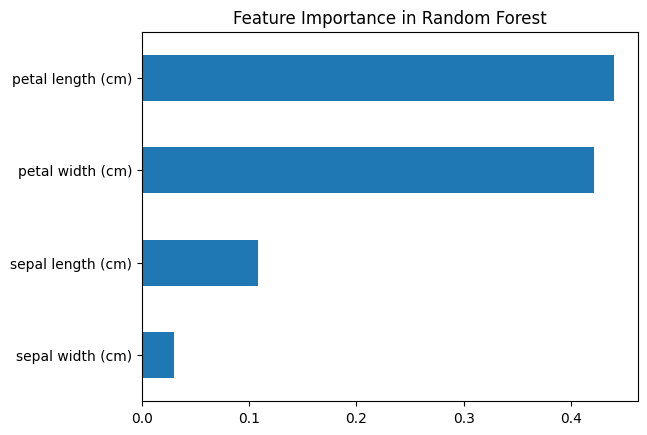

In [4]:
import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index=data.feature_names
)

feature_importance.sort_values().plot(kind="barh")

plt.title("Feature Importance in Random Forest")

plt.show()

This shows which features contribute the most to predictions.

# Summary

Random Forest is an ensemble learning method that combines
many decision trees.

Key concepts:

Bootstrap sampling

Feature randomness

Majority voting

Advantages:

High accuracy

Reduces overfitting

Works well on many datasets

Limitations:

Slower than a single tree

Less interpretable

Random Forest is widely used in:

Finance

Healthcare

Fraud detection

Recommendation systems